In [ ]:
import warnings
warnings.filterwarnings("ignore")

import os
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf

import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization,
    GlobalAveragePooling2D
)

In [ ]:
# This code segment is not 100% my own work. I was struggling with properly implementing the data from the kaggle dataset, so I utilized ChatGPT asking how to
# parse the directory and import it for the CNN model, while also showing it some lines from the transfer learning notes.
import kagglehub
from pathlib import Path

# Download dataset (cached after first run)
root_path = Path(kagglehub.dataset_download(
    "arjunbasandrai/25-indian-bird-species-with-226k-images"
))
print("Dataset downloaded to:", root_path)

# Point to the image directory (NOT the TFRecords)
image_root = root_path / "training_set" / "training_set"
if not image_root.exists():
    raise FileNotFoundError(
        f"Expected image folder not found: {image_root}\n"
        "Open the dataset root above and verify the structure."
    )
print("Using image directory:", image_root)

# Generators: keep shapes aligned with  model (128x128, sparse labels)
IMG_SIZE = (128, 128)
BATCH    = 32
VAL_SPLIT = 0.20

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=VAL_SPLIT,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=VAL_SPLIT
)

train_generator = train_datagen.flow_from_directory(
    directory=str(image_root),
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode="sparse",
    subset="training",
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    directory=str(image_root),
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode="sparse",
    subset="validation",
    shuffle=True
)

num_classes = len(train_generator.class_indices)
print("Classes detected:", num_classes)
print("First 10 class mappings:", dict(list(train_generator.class_indices.items())[:10]))
print("Train steps/epoch:", len(train_generator), "| Val steps/epoch:", len(val_generator))


Using Colab cache for faster access to the '25-indian-bird-species-with-226k-images' dataset.
Dataset downloaded to: /kaggle/input/25-indian-bird-species-with-226k-images
Using image directory: /kaggle/input/25-indian-bird-species-with-226k-images/training_set/training_set
Found 18106 images belonging to 25 classes.
Found 4514 images belonging to 25 classes.
Classes detected: 25
First 10 class mappings: {'Asian Green Bee-Eater': 0, 'Brown-Headed Barbet': 1, 'Cattle Egret': 2, 'Common Kingfisher': 3, 'Common Myna': 4, 'Common Rosefinch': 5, 'Common Tailorbird': 6, 'Coppersmith Barbet': 7, 'Forest Wagtail': 8, 'Gray Wagtail': 9}
Train steps/epoch: 566 | Val steps/epoch: 142


Number of classes: 25
Training images: 18106
Validation images: 4514
Example class mapping: {'Asian Green Bee-Eater': 0, 'Brown-Headed Barbet': 1, 'Cattle Egret': 2, 'Common Kingfisher': 3, 'Common Myna': 4}


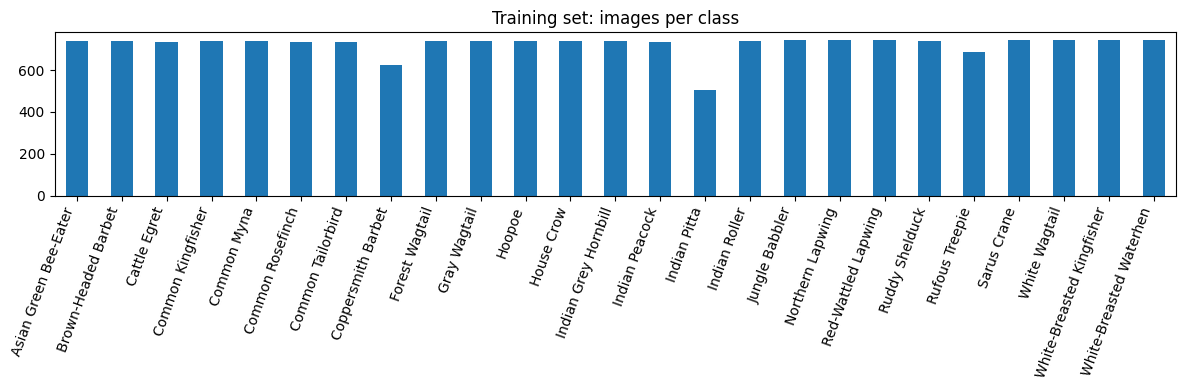

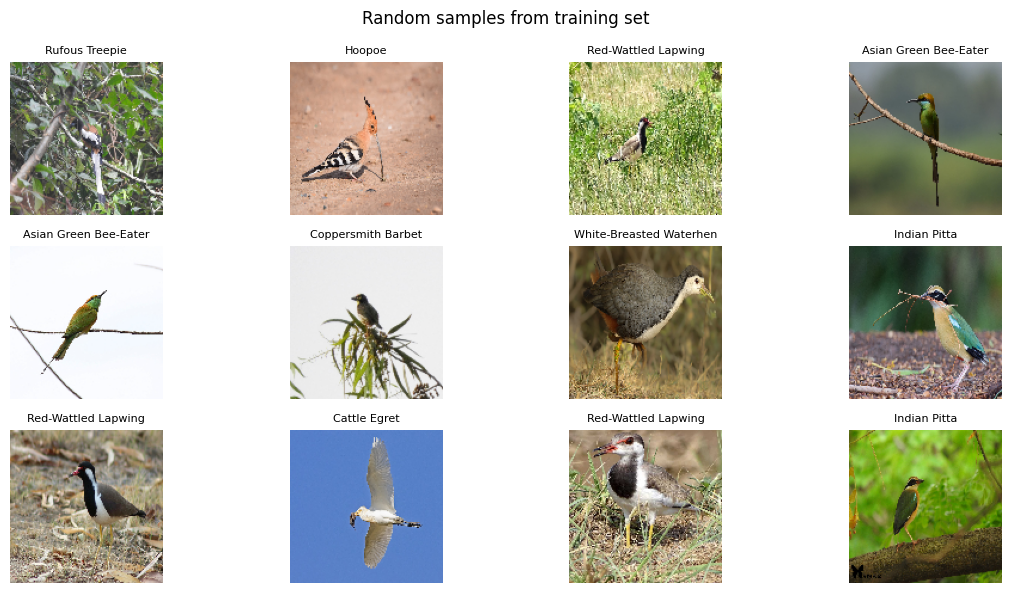

In [ ]:
#EDA
import os, random
from tensorflow.keras.utils import load_img

class_names = list(train_generator.class_indices.keys())
train_count = len(train_generator.filenames)
val_count   = len(val_generator.filenames)

print(f"Number of classes: {len(class_names)}")
print(f"Training images: {train_count}")
print(f"Validation images: {val_count}")
print("Example class mapping:", dict(list(train_generator.class_indices.items())[:5]))

#class count chart (train only)
labels = [fp.split(os.sep)[0] for fp in train_generator.filenames]
train_counts = pd.Series(labels).value_counts().sort_index()

plt.figure(figsize=(12,4))
train_counts.plot(kind="bar")
plt.title("Training set: images per class")
plt.xticks(rotation=70, ha="right")
plt.tight_layout()
plt.show()

#small image grid: 12 random samples from train split
sample_files = random.sample(train_generator.filenames, 12)
plt.figure(figsize=(12,6))
for i, relpath in enumerate(sample_files):
    img_path = os.path.join(train_generator.directory, relpath)
    plt.subplot(3,4,i+1)
    plt.imshow(load_img(img_path, target_size=IMG_SIZE))
    plt.title(relpath.split(os.sep)[0], fontsize=8)
    plt.axis("off")
plt.suptitle("Random samples from training set", fontsize=12)
plt.tight_layout()
plt.show()


In [ ]:
# Define CNN model
cnn_model = Sequential()

# Layer 1
cnn_model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D(pool_size=(2, 2)))

# Layer 2
cnn_model.add(Conv2D(64, (3, 3), activation='relu'))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D(pool_size=(2, 2)))

# Layer 3
cnn_model.add(Conv2D(128, (3, 3), activation='relu'))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D(pool_size=(2, 2)))

# Layer 4: Convolution + Batch Normalization
cnn_model.add(Conv2D(128, (3, 3), activation='relu'))
cnn_model.add(BatchNormalization())

# Layer 5: Convolution + Batch Normalization + Max Pooling
cnn_model.add(Conv2D(256, (3, 3), activation='relu'))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D(pool_size=(2, 2)))

# Fully Connected Layer
cnn_model.add(Flatten())
cnn_model.add(Dense(256, activation='relu'))
cnn_model.add(Dropout(0.5))

# Output Layer
cnn_model.add(Dense(25, activation='softmax'))

cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 10, 10, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 10, 10, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6400)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,638,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 25)             │         6,425 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,183,513 (8.33 MB)

 Trainable params: 2,182,297 (8.32 MB)

 Non-trainable params: 1,216 (4.75 KB)

In [ ]:
#training and evaluation
cnn_history = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20
)

test_loss, test_accuracy = cnn_model.evaluate(val_generator)
print(f"Test (using validation) Loss: {test_loss}")
print(f"Test (using validation) Accuracy: {test_accuracy}")


Epoch 1/20
566/566 ━━━━━━━━━━━━━━━━━━━━ 591s 1s/step - accuracy: 0.0589 - loss: 3.6515 - val_accuracy: 0.0673 - val_loss: 3.1663
Epoch 2/20
566/566 ━━━━━━━━━━━━━━━━━━━━ 424s 749ms/step - accuracy: 0.0677 - loss: 3.1573 - val_accuracy: 0.0955 - val_loss: 3.1115
Epoch 3/20
566/566 ━━━━━━━━━━━━━━━━━━━━ 436s 770ms/step - accuracy: 0.0827 - loss: 3.0881 - val_accuracy: 0.0835 - val_loss: 3.1437
Epoch 4/20
566/566 ━━━━━━━━━━━━━━━━━━━━ 422s 747ms/step - accuracy: 0.0927 - loss: 3.0244 - val_accuracy: 0.1265 - val_loss: 2.9596
Epoch 5/20
566/566 ━━━━━━━━━━━━━━━━━━━━ 418s 738ms/step - accuracy: 0.1181 - loss: 2.9690 - val_accuracy: 0.1761 - val_loss: 2.7809
Epoch 6/20
566/566 ━━━━━━━━━━━━━━━━━━━━ 416s 736ms/step - accuracy: 0.1292 - loss: 2.8526 - val_accuracy: 0.1779 - val_loss: 2.6520
Epoch 7/20
566/566 ━━━━━━━━━━━━━━━━━━━━ 421s 744ms/step - accuracy: 0.1482 - loss: 2.7518 - val_accuracy: 0.2319 - val_loss: 2.6678
Epoch 8/20
566/566 ━━━━━━━━━━━━━━━━━━━━ 417s 737ms/step - accuracy: 0.1777 - lo

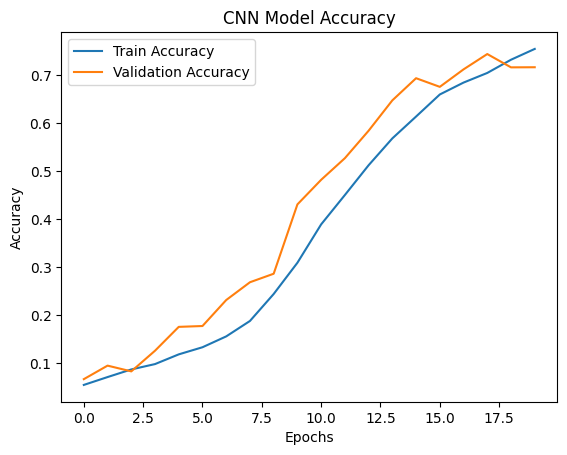

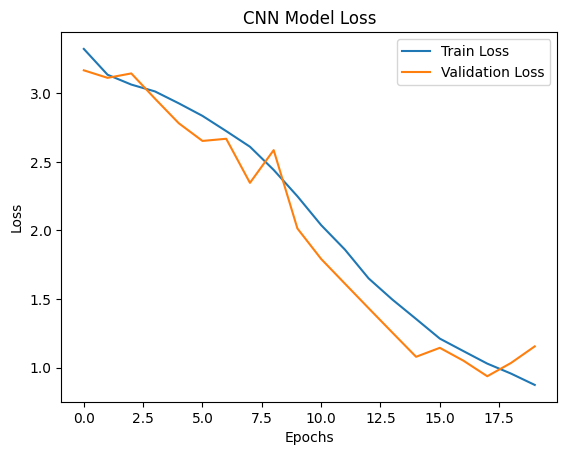

In [ ]:
# Plot CNN accuracy
plt.plot(cnn_history.history['accuracy'], label='Train Accuracy')
plt.plot(cnn_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot CNN loss
plt.plot(cnn_history.history['loss'], label='Train Loss')
plt.plot(cnn_history.history['val_loss'], label='Validation Loss')
plt.title('CNN Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
#custom layers
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
output = Dense(25, activation='softmax')(x)

transfer_model = Model(inputs=base_model.input, outputs=output)

# Freeze base model layers
for layer in base_model.layers:
    layer.trainable = False

# Compile the transfer model
transfer_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train Transfer Learning Model
transfer_history = transfer_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 464s 798ms/step - accuracy: 0.0588 - loss: 3.1969 - val_accuracy: 0.1021 - val_loss: 3.0592
Epoch 2/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 437s 771ms/step - accuracy: 0.0890 - loss: 3.0701 - val_accuracy: 0.1190 - val_loss: 2.9910
Epoch 3/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 438s 773ms/step - accuracy: 0.1152 - loss: 3.0015 - val_accuracy: 0.1367 - val_loss: 2.9165
Epoch 4/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 432s 762ms/step - accuracy: 0.1280 - loss: 2.9415 - val_accuracy: 0.1591 - val_loss: 2.8838
Epoch 5/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 434s 767ms/step - accuracy: 0.1395 - loss: 2.9109 - val_accuracy: 0.1599 - val_loss: 2.8434
Epoch 6/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 431s 762ms/step - accuracy: 0.1463 - loss: 2.8785 - val_accuracy: 0.1668 - val_loss: 2.8120
Epoch 7/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 438s 774ms/step - accuracy: 0.1620 - loss: 2.8457 - val_accuracy: 0.1586 - val_loss: 2.8118
Epoch 8/10
566/566 ━━━━━━

142/142 ━━━━━━━━━━━━━━━━━━━━ 75s 526ms/step - accuracy: 0.1858 - loss: 2.7376
Transfer Learning Test Loss: 2.7479352951049805
Transfer Learning Test Accuracy: 0.18830305337905884


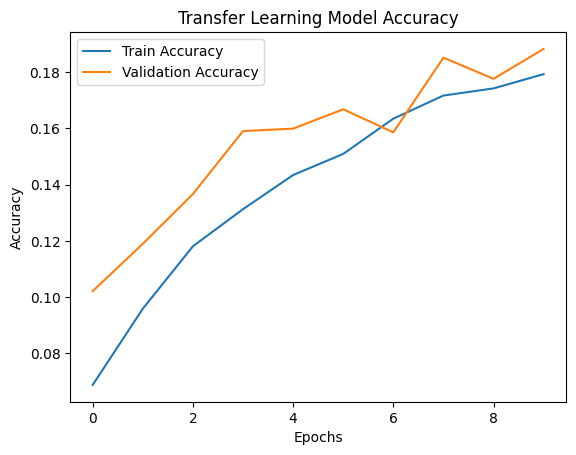

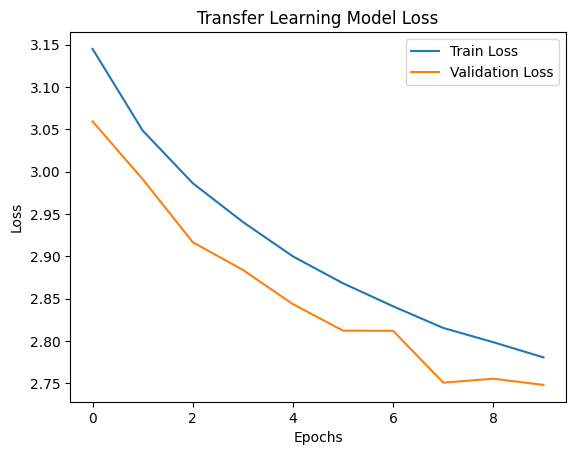

In [ ]:
# Evaluate the transfer model
transfer_test_loss, transfer_test_accuracy = transfer_model.evaluate(val_generator)
print(f"Transfer Learning Test Loss: {transfer_test_loss}")
print(f"Transfer Learning Test Accuracy: {transfer_test_accuracy}")

# Plot Transfer Learning accuracy
plt.plot(transfer_history.history['accuracy'], label='Train Accuracy')
plt.plot(transfer_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Transfer Learning Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot Transfer Learning loss
plt.plot(transfer_history.history['loss'], label='Train Loss')
plt.plot(transfer_history.history['val_loss'], label='Validation Loss')
plt.title('Transfer Learning Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()
